# Dark Matter indirect search analysis with Gammapy
This tutorial covers a full analysis pipeline for the indirect search of dark matter using Gammapy. We assume basic familiarity with Gammapy's data structures and the Dark Matter module. If you are new to Gammapy, we recommend first working through the introductory and the Dark Matter Basics and Data handling tutorials.

In this example we perform a **3D analysis** — using both spatial and spectral information, as opposed to a 1D (spectral-only) analysis (heck the 'Dark Matter Data Handling with Gammapy' tutorial for further details about these approaches).

To perform a dark matter analysis, we need to fit the data with a model that includes both the background and the dark matter signal component. Rather than fitting the physical parameters (e.g. the annihilation cross-section $\langle\sigma v\rangle$ or the decay lifetime $\tau$) directly, it is common practice to introduce a **scale parameter**, that rescales the predicted dark matter signal. Depending on the DM model assumed, the constrained quantity is different.

---

**Dark matter annihilation**

The expected gamma-ray flux from DM annihilation is:

$$\Phi_{\rm ann}(>E_{\rm min}) = \frac{\langle\sigma v\rangle}{8\pi m_\chi^2} 
\cdot J \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

The physical quantity of interest is the **velocity-averaged annihilation cross section** ⟨σv⟩. A larger ⟨σv⟩ means a brighter signal. A non-detection gives an **upper limit** on ⟨σv⟩: the DM particles annihilate *at most* this efficiently.

In Gammapy's `DarkMatterAnnihilationSpectralModel`, ⟨σv⟩ is encoded through a dimensionless **`scale`** parameter:

$$\text{scale} = \frac{\langle\sigma v\rangle}{\langle\sigma v\rangle_{\rm ref}}$$

where $\langle\sigma v\rangle_{\rm ref} \approx 3\times10^{-26}$ cm³ s⁻¹ is the thermal relic value. An upper limit on `scale` translates directly into an upper limit on ⟨σv⟩:

$$\langle\sigma v\rangle < \text{scale}_{\rm UL} \times \langle\sigma v\rangle_{\rm ref}$$

---

**Dark matter decay**

The expected gamma-ray flux from DM decay is:

$$\Phi_{\rm dec}(>E_{\rm min}) = \frac{1}{4\pi \tau_\chi m_\chi} 
\cdot D \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$
The physical quantity of interest is the **DM lifetime** τ_χ. Note that it appears in the **denominator**: a *longer* lifetime means a *fainter* signal — the opposite behaviour from the annihilation case. A non-detection gives a **lower limit** on τ_χ: the DM particle must live *at least* this long.

In Gammapy's `DarkMatterDecaySpectralModel`, the lifetime is encoded through the same **`scale`** parameter, but now it multiplies the **decay rate** (inverse lifetime):

$$\text{scale} = \frac{1/\tau_\chi}{1/\tau_{\rm ref}} = \frac{\tau_{\rm ref}}{\tau_\chi}$$

where $\tau_{\rm ref}$ is an internal reference value (`LIFETIME_AGE_OF_UNIVERSE` ≈ 4.3 × 10¹⁷ s). Because of the inverse relationship, an **upper** limit on `scale` becomes a **lower** limit on τ_χ:

$$\tau_\chi > \frac{\tau_{\rm ref}}{\text{scale}_{\rm UL}}$$

This approach decouples the statistical treatment from the specific physical model: once we obtain the best-fit value of the scale and its uncertainty, we can translate it directly into a constraint on $\langle\sigma v\rangle$ or $\tau$ through the linear relation above.


In this way, the steps/sections followed in this tutorial are:

1. **Data.** We obtain and manage the data to be analyzed. In this case, this corresponds to a 3D dataset (spatial + spectral information).
2. **Analysis of signal detection.** We perform a statistical test to determine whether the dataset contains a genuine signal or is compatible with background only, and outline the procedure to follow in each case.
3. **Obtaining limits.**
   - *No signal detected*: we derive upper limits on the dark matter cross-section (or decay lifetime).
   - *Signal detected*: we derive confidence intervals on the signal parameters.
4. **Exclusion curve: scanning over masses.** We repeat the limit-setting procedure over a grid of dark matter masses to build the exclusion curve.
5. **Bands plot: uncertainty bands on the exclusion curve.** We compute the expected sensitivity and its uncertainty bands (1σ/2σ) around the exclusion curve, following the standard bands plot convention.


**Prerequisites**

- Understanding of the Dark Matter basics, see the tutorial 'Dark Matter Indirect Detection with Gammapy: Basics'
- Familiarity with the Dark Matter Data handling, check the tutorial 'Dark Matter Data Handling with Gammapy'

## Setup

In [2]:
# sphinx_gallery_thumbnail_number = 8
from gammapy.datasets import MapDataset, Datasets
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel,
)
from gammapy.modeling import select_nested_models
from gammapy.astro.darkmatter import (
    DarkMatterDecaySpectralModel,
    profiles,
    JFactory
)
from gammapy.modeling import Fit
from gammapy.estimators import ParameterEstimator

from regions import CircleSkyRegion

import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


## Analysis of a Dark Matter source

### 1. Data

For this tutorial we will use the data of a non-signal dataset provided by the Gammapy database.. Additionally, we are going to consider that the data follows an Einasto profile and we are going to study the case of Decay with channel b.

**For further detail in this step or if you want to use Real Data please check the tutorial 'Dark Matter Data Handling with Gammapy'.**

In [3]:
# We obtain the data
dataset = MapDataset.read("$GAMMAPY_DATA/datasets/empty-dl4/empty-dl4.fits.gz")

In [4]:
dataset.meta_table

TELESCOP,OBS_ID,OBS_MODE,RA_PNT,DEC_PNT,AZ_PNT,ALT_PNT,TSTART,TSTOP,MJDREFI,MJDREFF,TIMESYS,GEOLON,GEOLAT,ALTITUDE
,,,deg,deg,deg,deg,,,,,,,,
str4,int64,str8,float64,float64,float64,float64,float64,float64,int64,float64,str2,float64,float64,float64
HESS,20275,POINTING,187.27791666667,2.5523888888889,49.1449182625829,53.8175685733296,4588689100.184,4588690783.184,0,0.0,tt,16.5002222222222,-23.271777777777796,1834.9999999997835


We can see that only one observation is on the dataset, so we are not going to perform any data selection or reduction (see the tutorial in the Dark Matter Data Handling how to do it). The observation pointing is towards M87, so we are going to take it as a reference.

In [5]:
# We set our target position. In this case we use the same as in the dataset, since we only have one observation. Let's pretend we are interested on that source
target_pos = SkyCoord(ra=187.27791666667 * u.deg, dec=2.55238888889 * u.deg, frame="icrs")
target_dist = 16400 * u.kpc

# Set energy bounds
energy_edges = np.logspace(-1, 1.5, 15)
# The reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
# In this case we use the same for true and reco, but it depends on your energy range study.
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")

# Geometry map we are going to work with
geom = WcsGeom.create(
    binsz=0.1, # Pixel size
    skydir=target_pos, # Sky position of the target, center of the map
    width=3.0, # Width of the map (i.e 3x3 map)          
    frame="icrs", # Coordinates system
    axes=[energy_reco] 
)

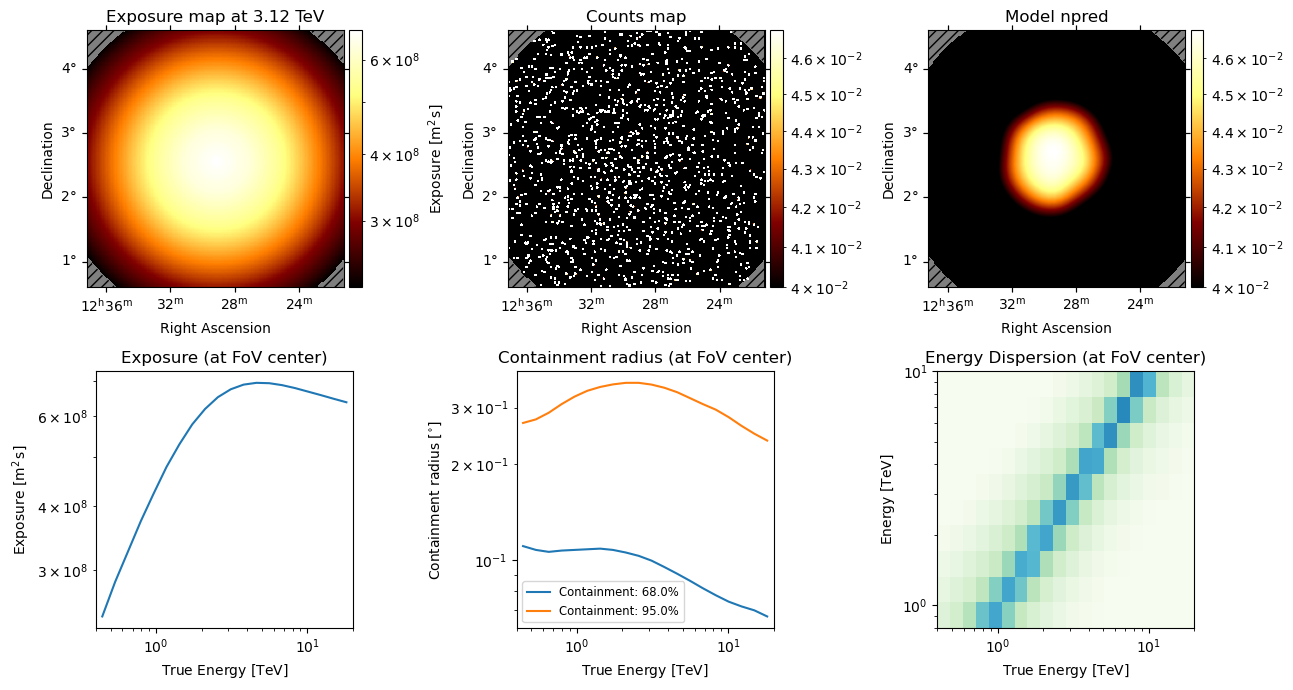

In [6]:

# DM Spatial distribution

spatial_model = PointSpatialModel(
    lon_0=target_pos.ra,
    lat_0=target_pos.dec,
    frame="icrs"
)
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

# This density data is not accurate for M87, but we set these values as examples
r_s = 0.91 * u.kpc # Scale radius
rho_s = 1.3e7 * (u.M_sun / u.kpc**3) # Scale density
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy()) # Units conversion

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV
)

# Dfactor - This can also be calculated with the class JFactory, but we set the value for simplicity. You can look for it in dedicated papers.
dfactory = JFactory(
    geom=geom, # Geometry map
    profile=profile, # Chosen density profile
    distance=target_dist, # Target distance
    annihilation = False # Set if it is annihilation (true) or decay (false)
)

# Computation of the J factor
dfact = dfactory.compute_jfactor() 

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=target_pos, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom.wcs)

# Integration of DFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact).sum()

spectral_model = DarkMatterDecaySpectralModel(
    mass=massDM,
    channel=channel, 
    jfactor=total_dfact, 
    scale=0 # Example so we do NOT get a signal
)

# Combined model
sky_model = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="dm"
)

bkg_model = FoVBackgroundModel(dataset_name=dataset.name)

# Attach the DM model and a Field-of-View background model
dataset.models = Models([sky_model, bkg_model])

dataset.peek()

### 2. Analysis of signal detection
To verify that our dataset contains no dark matter signal, we perform a **likelihood ratio test** between two hypotheses:

- **H₀ (background-only):** the dataset is described by the background model alone
- **H₁ (signal + background):** a dark matter spectral component is included

We fit both models to the dataset and compute the Test Statistic - the fitting technical details will be explained in the next sections:

$$\text{TS} = -2\ln\frac{\mathcal{L}(\text{H}_0)}{\mathcal{L}(\text{H}_1)} = \text{stat}_{H_0} - \text{stat}_{H_1}$$

For the case of one degree of freedom (i.e. a single free parameter between $H_0$ and $H_1$, as is the case here with `scale`), Wilks' theorem gives $\text{TS} \sim \chi^2_1$, so $\sqrt{\text{TS}}$ approximates the detection significance in Gaussian sigmas — a value of TS  = 25 corresponds to a $5\sigma$ detection. The brighter the injected signal, the larger the TS. Under the background-only hypothesis, we expect **TS ≈ 0**, meaning the fitter finds no evidence for a dark matter signal in the data.

Gammapy's `Fit` class provides a unified interface to several optimization backends; by default it uses [iminuit](https://iminuit.readthedocs.io/), a Python wrapper around the MINUIT2 C++ library originally developed at CERN, the de facto standard optimizer in high-energy and astroparticle physics. MINUIT performs a maximum-likelihood fit and additionally provides robust parameter errors and covariance estimates via the Hesse and Minos algorithms.

During the fit, the optimizer adjusts all **free** parameters of the model — the background normalization parameters (or `scale` (related to ⟨σv⟩ or 1/τ_χ, depending on whether we are studying annihilation or decay) if you are making a signal study) — to maximize the Poisson likelihood between the observed (or simulated) counts and the model prediction. All other parameters remain fixed at their assumed values.

Not all model parameters are varied during the fit: each parameter can be set as **free** or **frozen**, and free parameters can further be given **bounds** (min/max values) to keep the fit within a physically meaningful range. Typically, the background normalization is left free to absorb residual mismatches between the assumed and true background level, while the spectral shape parameters (e.g. the DM mass or the spectral channel) are kept fixed to the values under study, leaving only the **`scale`** parameter (related to ⟨σv⟩ or 1/τ_χ, depending on whether we are studying annihilation or decay) free to vary. During the fit, the optimizer adjusts all free parameters of the model to maximize the Poisson likelihood between the observed (or simulated) counts and the model prediction, while all fixed parameters remain at their assumed values.


In [7]:
# First check the parameters of the model
print(dataset.models.parameters.to_table())

type    name     value    unit   error      min        max    frozen link prior
---- --------- ---------- ---- --------- ---------- --------- ------ ---- -----
         scale 0.0000e+00      0.000e+00        nan       nan  False           
         lon_0 1.8728e+02  deg 0.000e+00        nan       nan  False           
         lat_0 2.5524e+00  deg 0.000e+00 -9.000e+01 9.000e+01  False           
          tilt 0.0000e+00      0.000e+00        nan       nan   True           
          norm 1.0000e+00      0.000e+00        nan       nan  False           
     reference 1.0000e+00  TeV 0.000e+00        nan       nan   True           


We see that the coordinates are free parameters, we should freeze them so we make sure we study the target we want.

In [8]:
dataset.models["dm"].parameters['lon_0'].frozen = True
dataset.models["dm"].parameters['lat_0'].frozen = True

In [9]:
# Fit with background only (no DM signal)
# Freeze the DM model parameters and free the background model parameters
dataset.models["dm"].spectral_model.scale.frozen = True
dataset.models["stacked-bkg"].parameters["norm"].frozen = False
dataset.models["stacked-bkg"].parameters["tilt"].frozen = False

# Example of how to set the background normalization parameter for a specific dataset. This is useful when you want to adjust the background model's normalization before fitting or analyzing the data.
dataset.models["stacked-bkg"].parameters["norm"].value = 1.0 # Starting point of the optimizer
dataset.models["stacked-bkg"].parameters["norm"].min = 0.5
dataset.models["stacked-bkg"].parameters["norm"].max = 2.0

fit = Fit()
result_bkg = fit.run(datasets=[dataset])
print(f"Background fit converged: {result_bkg.success}")

if not result_bkg.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0 = dataset.stat_sum()
    print(f"         stat_H0 = {stat_H0:.4f}")

Background fit converged: True
         stat_H0 = 16308.6190


In [10]:
# Another way to do the background-only fit is to create a new model with only the background component and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample with a mock dataset
fit = Fit()
result_nosrc = fit.run(datasets=[dataset])
if not result_nosrc.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0_nosrc = dataset.stat_sum()
    print(f"         stat_H0 = {stat_H0_nosrc:.4f}")

         stat_H0 = 16308.6190


Once it has converged, we can proceed with the H1 fit.

In [11]:
# Full fit — all parameters free
dataset.models["stacked-bkg"].parameters["norm"].frozen = False
dataset.models["stacked-bkg"].parameters["tilt"].frozen = False
dataset.models["dm"].spectral_model.scale.frozen = False

result_full = fit.run(datasets=[dataset])
print(f"Full fit converged: {result_full.success}")

if not result_full.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H1 = result_full.total_stat
    print(f"         stat_H1 = {stat_H1:.4f}")


Full fit converged: True
         stat_H1 = 16308.4678


In [12]:
#Another way to do the full fit is to create a new model with both the DM and background components and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample
dataset.models["stacked-bkg"].parameters["norm"].frozen = False
dataset.models["stacked-bkg"].parameters["tilt"].frozen = False
dataset.models["dm"].spectral_model.scale.frozen = False

result_src = fit.run(datasets=[dataset])
if not result_src.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")

finally, when both fits are successful, we can proceed with he calculation of the TS.

In [13]:
TS = stat_H0 - stat_H1
print(f"TS = {TS:.2f}")  # Expected ~ 0 for background-only dataset

TS = 0.15


As aforementioned, the TS value is expected to be around 0 for a background-only dataset, indicating that the addition of the DM signal does not significantly improve the fit.

### Another method: `select_nested_models`

Alternatively, `select_nested_models` automates this nested-hypothesis test internally: it keeps the background and all other sources in the field of view free and identical in both fits, and only freezes the DM `scale` parameter to 0 for H0, restoring its original state afterwards.


In [14]:
result = select_nested_models(
    datasets=Datasets(dataset),
    parameters=[spectral_model.parameters["scale"]],
    null_values=[0],
)

TS = result["ts"]
print(f"TS = {TS:.4f}")

TS = 0.1512


Additionally, we can make a visual check of our data to verify this result.

[]

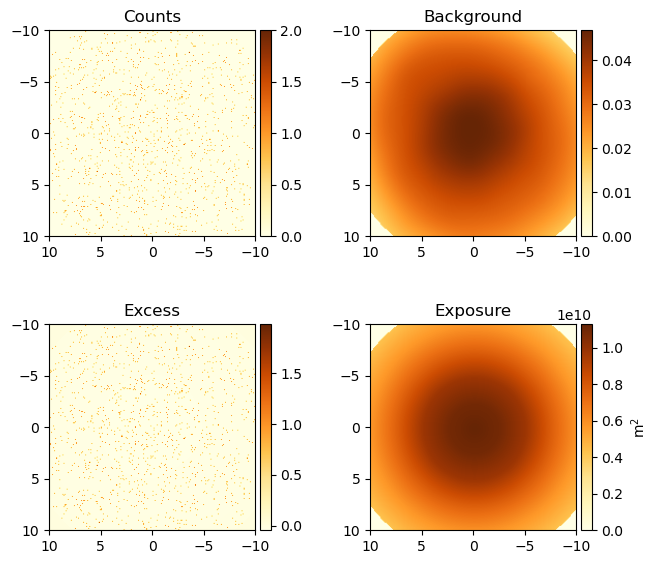

In [15]:
fig_peek, axs = plt.subplots(2,2, figsize=(7,7))

img_1 = axs[0,0].imshow(
    np.sum(dataset.counts.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr',
)
axs[0,0].set_title('Counts')
divider = make_axes_locatable(axs[0,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_1 = fig_peek.colorbar(img_1, cax=cax, orientation='vertical')

img_2 = axs[0,1].imshow(
    np.sum(dataset.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[0,1].set_title('Background')
divider = make_axes_locatable(axs[0,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_2 = fig_peek.colorbar(img_2, cax=cax, orientation='vertical')

img_3 = axs[1,0].imshow(
    np.sum(dataset.counts.data, axis=0) - np.sum(dataset.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,0].set_title('Excess')
divider = make_axes_locatable(axs[1,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_3 = fig_peek.colorbar(img_3, cax=cax, orientation='vertical')

img_4 = axs[1,1].imshow(
    np.sum(dataset.exposure.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,1].set_title('Exposure')

divider = make_axes_locatable(axs[1,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_4 = fig_peek.colorbar(img_4, cax=cax, orientation='vertical')
cbar_4.ax.set_ylabel(r'm$^2$')

fig_peek.subplots_adjust(wspace=0.45, hspace=0.2)

plt.plot()

[]

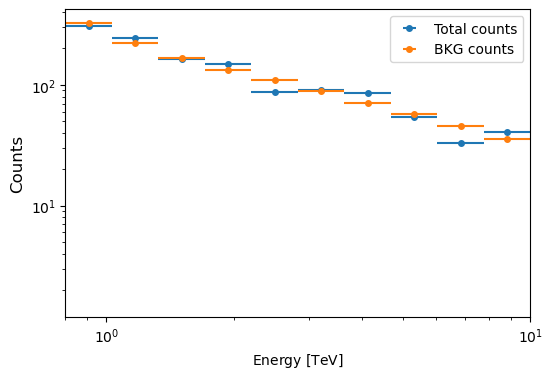

In [16]:
# Let's check the spectrum and the different contributions
spec, axs = plt.subplots(1, 1, figsize=(6, 4))
dataset.counts.get_spectrum().plot(label='Total counts')
dataset.npred_background().get_spectrum().plot(label='BKG counts')

axs.set_ylabel('Counts', fontsize=12)
axs.legend()
plt.plot()

#### Residuals

After fitting the model, it is important to check the residuals to assess how well the model (source + background) describes the data. The residuals are computed as the difference between the observed counts and the predicted counts (`npred`), optionally normalized by the Poisson uncertainty:

- `diff`: simple residual, `counts - npred`
- `diff/sqrt(model)`: significance-like residual, `(counts - npred) / sqrt(npred)`
- `diff/model`: fractional residual, `(counts - npred) / npred`

The **spatial residuals map** shows whether there is any remaining structure in the field of view not captured by the model (e.g. an unmodeled source or background mismatch). The **spectral residuals** show whether the model reproduces the energy
distribution of the counts correctly, or if there are systematic deviations in specific energy bins.

A well-fitted model should show residuals fluctuating around zero, without significant structure or trends, both spatially and in energy.


<WCSAxes: >

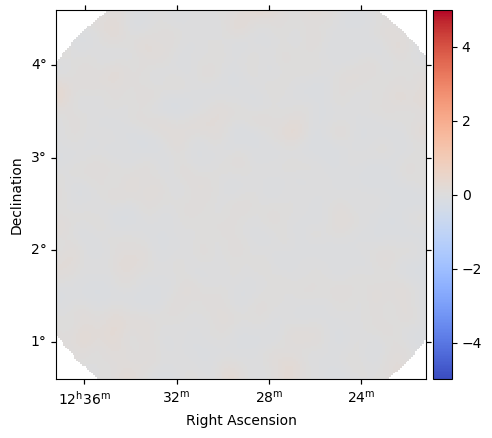

In [17]:
# Spatial residuals map
dataset.plot_residuals_spatial(
    method="diff/sqrt(model)",
    smooth_kernel="gauss",
    smooth_radius=0.1 * u.deg,
    cmap="coolwarm",
    vmin=-5,
    vmax=5,
    add_cbar=True,
)

<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='Residuals ((data - model) / sqrt(model))'>

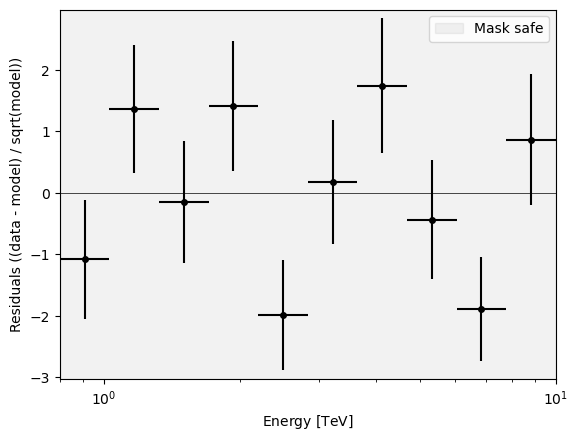

In [18]:
# Spectral residuals (residual counts vs energy)
dataset.plot_residuals_spectral(
    method="diff/sqrt(model)",
)

Alternatively, the `TSMapEstimator` or `ExcessMapEstimator` can be used to inspect residuals, providing a significance-based map instead of a simple count/flux residual.

### 3. Obtaining limits

#### The Profile Likelihood

We use the **profile likelihood** to derive both upper limits and confidence intervals. The idea is simple: we scan `scale` over a grid of values and ask how much the likelihood degrades at each point, relative to its best-fit value:

$$\Delta \text{TS}(\text{scale}) = \text{stat}(\text{scale}) - \text{stat}(\hat{\text{scale}})$$

where $\hat{\text{scale}}$ is the best-fit value. By construction, $\Delta\text{TS} = 0$ at $\text{scale} = \hat{\text{scale}}$, and it increases as `scale` moves away from the best fit in either direction.

By Wilks' theorem, $\Delta\text{TS}$ asymptotically follows a $\chi^2$ distribution, and the critical value used to define a confidence region depends on **how many sides** of the distribution we constrain — this is where the two scenarios from the previous section come in:

- **No signal detected → one-sided upper limit.** Since a non-detection only constrains `scale` from above (there is no physical lower bound below `scale = 0`), we use a **one-sided** test. The 95% CL upper limit corresponds to the value of `scale` where:

  $$\boxed{\Delta \text{TS} = 2.71}$$

  (equivalent to a one-tailed Gaussian significance of $1.645\sigma$).

- **Signal detected → two-sided confidence interval.** Since we now have a non-zero best-fit value, we bracket it symmetrically from both sides, using a **two-sided** test. The 95% CL interval is defined by the two values of `scale` (one below $\hat{\text{scale}}$, one above) where:

  $$\boxed{\Delta \text{TS} = 3.84}$$

  (equivalent to a two-tailed Gaussian significance of $1.96\sigma$).

In both cases, the procedure is the same — scan `scale`, compute $\Delta\text{TS}$, and find where it crosses the relevant threshold — only the threshold value and whether we search one or both directions changes, depending on the outcome of the signal-detection test.

The decision of which quantity to report is not a stylistic choice: reporting a one-sided upper limit when TS indicates a clear detection would hide the fact that a signal was found, while reporting a two-sided interval when TS ≈ 0 would misleadingly suggest a measurement where there is only background fluctuation (see e.g. Feldman & Cousins 1998; Rolke et al. 2005). A simple decision rule based on the value of TS is typically used to choose between the two regimes automatically.

While the 95% confidence level is the standard choice in indirect dark matter searches (and the convention we adopt throughout this tutorial), the same profile likelihood procedure can be used to derive limits or intervals at any other confidence level, simply by using the corresponding $\Delta\text{TS}$ threshold (e.g. $\Delta\text{TS} = 1$ for 68% CL, one-sided).


In Gammapy, the profile likelihood is computed with the `Fit.stat_profile()` method: given a dataset with the model already fitted, `stat_profile` fixes its internal `scale` parameter (not our goal parameter, they are called the same but they differ) to each value in a user-defined grid, re-optimizes all other free parameters at each point, and returns the corresponding `stat` (and hence $\Delta\text{TS}$) values, from which the desired confidence limit or interval can be read off.

#### 3.1. No signal detected

We did not detect a signal, but we can still place a **constraint** on the DM parameter of interest — we can exclude signal amplitudes large enough to be inconsistent with what we observed.


In [19]:
# Reset scale to a clean starting point
spectral_model.scale.value  = 1e-6
spectral_model.scale.min    = 0
spectral_model.scale.max    = None
spectral_model.scale.frozen = False

# Release background parameters
dataset.models["stacked-bkg"].parameters["norm"].frozen = False
dataset.models["stacked-bkg"].parameters["tilt"].frozen = False

scale_par = dataset.models["dm"].spectral_model.scale
# Set a range of values to scan over for the scale parameter. This is useful for performing a profile likelihood scan to explore how the likelihood changes with different values of the scale parameter.
# In this cases it is from 1e-4 to 1e-2 with 20 points, which allows for a detailed exploration of the parameter space.
scale_par.scan_values = np.logspace(-4, -2, 20) 

print(f"Scan range:       {scale_par.scan_values.min():.1e}"
      f" — {scale_par.scan_values.max():.1e}")
print(f"Number of points: {len(scale_par.scan_values)}")
print("Running profile scan...")

# Run the profile likelihood
profile = fit.stat_profile(
    datasets=dataset,
    parameter=scale_par,
    reoptimize=True,    # re-optimize background at each scan point
)

print("Profile scan completed ✓")

Scan range:       1.0e-04 — 1.0e-02
Number of points: 20
Running profile scan...
Profile scan completed ✓


In [20]:
# Extract arrays──
scale_scan = profile["dm.spectral.scale_scan"]
delta_ts   = profile["stat_scan"] - profile["stat_scan"].min()

# Sanity checks───
print(f"Minimum ΔTS: {delta_ts.min():.4f}  (should be ≈ 0)")
print(f"Maximum ΔTS: {delta_ts.max():.2f}   (must be > 2.71 to find UL)")

Minimum ΔTS: 0.0000  (should be ≈ 0)
Maximum ΔTS: 14.50   (must be > 2.71 to find UL)


We see that the maximum ΔTS is bigger than 2.71, so we can compute the upper limit of the scale and convert it into a physical value for our study case. If this wasn't the case, we must reconsiderer the configuration for the scan (i.e. scan_max...) and run again.

In [21]:
# Find scale_ul: crossing at ΔTS = 2.71 on the right branch ────────────────
# We interpolate only on the right side of the minimum (upper limit side)
idx_min  = np.argmin(delta_ts)
scale_ul = np.interp(2.71,
                     delta_ts[idx_min:],
                     scale_scan[idx_min:])

# Convert to physical limits ────────────────────────────────────────────────

# Decay: scale = τ_ref / τ_χ  →  τ_χ > τ_ref / scale_ul
tau_ref         = spectral_model.LIFETIME_AGE_OF_UNIVERSE   # ~4.3e17 s
tau_lower_limit = tau_ref / scale_ul

#Here you have the example for the case of annihilation, but we are not going to use it in this tutorial since we are working with decay.
# Annihilation (for reference): scale = <σv> / <σv>_ref  →  <σv> < scale_ul × <σv>_ref
# sigma_v_ref = 3e-26 * u.Unit("cm3 s-1")
# sigma_v_ul  = scale_ul * sigma_v_ref

print(f"  DM mass:    {massDM}")
print(f"  Channel:    {channel}")
print(f"  scale UL (95% CL):          {scale_ul:.3e}")
print(f"  Lifetime lower limit (95% CL): {tau_lower_limit:.3e} s")

  DM mass:    10.0 TeV
  Channel:    b
  scale UL (95% CL):          3.714e-03
  Lifetime lower limit (95% CL): 1.158e+20 s s


Here we can see that we have our limit con the decya lifetime computed and translated into physical units. Now we plot the profile likelihood.

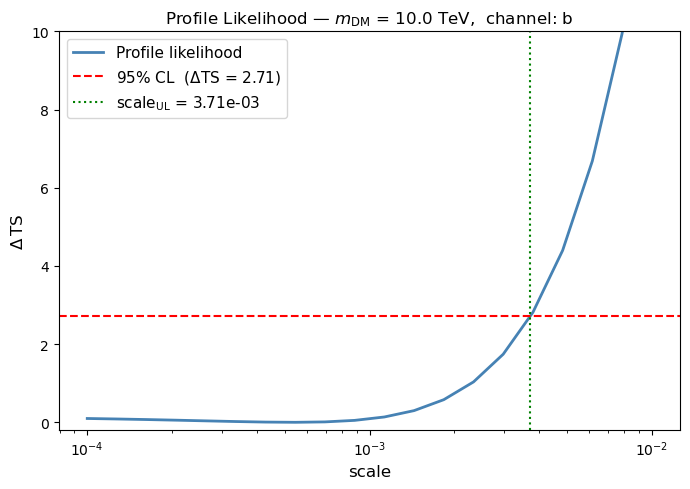

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

# Profile curve───
ax.plot(scale_scan, delta_ts,
        color="steelblue", linewidth=2,
        label="Profile likelihood")

# 95% CL threshold
ax.axhline(2.71,
           color="red", linestyle="--", linewidth=1.5,
           label=r"95% CL  ($\Delta$TS = 2.71)")

# Upper limit marker ────────────────────────────────────────────────────────
ax.axvline(scale_ul,
           color="green", linestyle=":", linewidth=1.5,
           label=f"scale$_{{\\rm UL}}$ = {scale_ul:.2e}")

ax.set_xscale("log")
ax.set_xlabel("scale", fontsize=12)
ax.set_ylabel(r"$\Delta\,\mathrm{TS}$", fontsize=12)
ax.set_ylim(-0.2, 10)
ax.legend(fontsize=11)
ax.set_title(
    rf"Profile Likelihood — $m_{{\rm DM}}$ = {massDM},  "
    rf"channel: {channel}",
    fontsize=12
)
plt.tight_layout()
plt.show()

The minimum sits at `scale ≈ 0`, as expected for a background-only dataset: the data show no preference for a nonzero DM signal. The curve rises monotonically from there — more signal means more predicted counts than observed, so the fit degrades and ΔTS grows.

The **95% CL upper limit** is where the curve crosses ΔTS = 2.71 (Wilks' theorem, one-sided test on a boundary parameter). Everything to the right is excluded; everything to the left remains compatible with the data.

Because the minimum sits at the boundary with ΔTS ≈ 0 throughout (no hint of detection), a **one-sided limit** is the correct quantity to report here — not a two-sided interval (see the aside below on what would change if TS were large instead). Converting `scale_ul` to a lower limit on $\tau_\chi$ is just a change of variable on this same statement: *decay lifetimes shorter than this value are excluded at 95% CL*.

For the decay case, this translates into a **lower limit on the DM lifetime**: the DM particle must live at least as long as $\tau_\chi > \tau_{\rm ref} / \text{scale}_{\rm UL}$. For the annihilation case, it gives an **upper limit on the annihilation cross section**: $\langle\sigma v\rangle < \text{scale}_{\rm UL} \times \langle\sigma v\rangle_{\rm ref}$.

### Another method: `ParameterEstimator`

`ParameterEstimator` can give you the best fit, symmetric error, TS, and (optionally) upper limit in one call. It doesn't return a two-sided profile-likelihood interval directly (that's what the manual scan above is for), but it's a fast sanity check on the significance and the Hessian error.

In [23]:
estimator = ParameterEstimator(
    n_sigma=1, # level for symmetric error (1σ = 68%)
    n_sigma_ul=1.645, # level for upper limit
    selection_optional=["ul"], # ask to also compute the UL
)
result_par = estimator.run(datasets=[dataset], parameter="scale")

print(f"Scale (best fit)      : {result_par['scale']:.4g}")
print(f"Scale upper limit     : {result_par['scale_ul']:.4g}")
print(f"TS                    : {result_par['ts']:.2f}")
print(f"sqrt(TS)              : {np.sqrt(max(result_par['ts'], 0)):.2f} sigma")

Scale (best fit)      : 0.000547
Scale upper limit     : 0.003713
TS                    : 0.15
sqrt(TS)              : 0.39 sigma



#### 3.2. Signal detected

If the fit above had returned **TS ≫ 0** (instead of TS ≈ 0), the interpretation — and the quantity we report — would change. A one-sided upper limit is only meaningful when the best-fit value sits at or near the physical boundary (`scale = 0`), i.e. when there is **no evidence for a signal**.

If a real signal were present, we would **stop here** and instead report a **best-fit value with a two-sided confidence interval**, using the *same* profiled likelihood but reading it differently:

$$\Delta \text{TS} = 1.0 \;\Rightarrow\; \text{68\% CL interval}$$
$$\Delta \text{TS} = 3.84 \;\Rightarrow\; \text{95\% CL interval}$$

read on **both branches** of the minimum, around the best-fit $\hat{\text{scale}}$ — not just the upper branch from zero as in the one-sided limit above.

The code below illustrates how this would look — **it is not executed in this tutorial**, since our dataset has TS ≈ 0 and the one-sided limit above is the correct result to report.

In [24]:
# EXAMPLE ONLY — not executed in this tutorial (TS ≈ 0 here) ──────────────
# This is what you would run instead of the one-sided UL block above,
# if the fit had returned TS >> 0 (a real detection).
idx_min  = np.argmin(delta_ts)
best_fit = scale_scan[idx_min]

lo_branch = delta_ts[:idx_min + 1]
hi_branch = delta_ts[idx_min:]

print(f"Best-fit scale          : {best_fit:.3e}")

# Two-sided confidence intervals (both branches around the minimum)
for cl_label, delta_ts_threshold in [("68%", 1.0), ("95%", 3.84)]:
    scale_lo = np.interp(delta_ts_threshold, lo_branch[::-1], scale_scan[:idx_min + 1][::-1])
    scale_hi = np.interp(delta_ts_threshold, hi_branch,       scale_scan[idx_min:])
    print(f"{cl_label} CL interval on scale : [{scale_lo:.3e}, {scale_hi:.3e}]")

    # Converted to the physical quantity (decay case)
    tau_ref  = spectral_model.LIFETIME_AGE_OF_UNIVERSE
    tau_best = tau_ref / best_fit
    tau_hi   = tau_ref / scale_lo   # inverse relation: swap bounds
    tau_lo   = tau_ref / scale_hi
    print(f"{cl_label} CL interval on tau   : [{tau_lo:.3e}, {tau_hi:.3e}]")

Best-fit scale          : 5.456e-04
68% CL interval on scale : [1.000e-04, 2.299e-03]
68% CL interval on tau   : [1.870e+20 s, 4.300e+21 s]
95% CL interval on scale : [1.000e-04, 4.467e-03]
95% CL interval on tau   : [9.625e+19 s, 4.300e+21 s]


### 4. Exclusion Curve: Scanning Over Masses

So far we have derived an upper limit for a single DM mass. To build the full **exclusion curve** — the standard output of a DM indirect detection analysis — we repeat the same procedure over a grid of masses.

For each mass we:
1. Update the spectral model to the new mass
2. Simulate a background-only dataset
3. Fit the background
4. Run the profile scan → `scale_ul`
5. Convert to a physical limit (τ_χ or ⟨σv⟩)

The result is a curve of lower limits on τ_χ (or upper limits on ⟨σv⟩) as a function of DM mass.

Below you can find the code for making the scan, but in this tutorial we will not run it because it can take sereval minutes.

In [25]:
# # Mass range we want to scan. In this case we scan 40 masses, for instance.
# masses = np.logspace(2, 4, 40) * u.GeV

# # Scan grid (adjust if needed per mass)
# scale_values = np.logspace(-10, -2, 100)

# # Output containers
# results = {
#     "mass"     : [],
#     "scale_ul" : [],
#     "scale_ll"   : []   # lower limit on scale
# }

# fit = Fit()

# print(f"Running exclusion curve over {len(masses)} masses...")
# for mass in masses:

#     print(f"  mass = {mass}  ...", end=" ")

#     spectral_model_m = DarkMatterDecaySpectralModel(
#         mass=mass,
#         channel=channel,
#         jfactor=total_dfact,
#     )
#     spectral_model_m.scale.value  = 0
#     spectral_model_m.scale.frozen = True
#     spectral_model_m.scale.min    = 0

#     bkg_model_m = FoVBackgroundModel(dataset_name=f"dataset-{mass.value:.0f}GeV")
#     bkg_model_m.parameters["norm"].frozen = False
#     bkg_model_m.parameters["tilt"].frozen = False

#     dataset_m = dataset.copy(name=f"dataset-{mass.value:.0f}GeV")
#     sky_model_m = SkyModel(
#         spatial_model=spatial_model,
#         spectral_model=spectral_model_m,
#         name="dm"
#     )
#     dataset_m.models = Models([sky_model_m, bkg_model_m])

#     # Fit background
#     result_bkg_m = fit.run(datasets=[dataset_m])
#     if not result_bkg_m.success:
#         print("background fit did not converge, skipping.")
#         continue

#     # Sanity check: signal changes with scale
#     spectral_model_m.scale.value = 1e-7
#     npred_sig = dataset_m.npred_signal().data.sum()
#     print(f"npred_signal = {npred_sig:.4e}", end=" ... ")
#     spectral_model_m.scale.value = 0

#     # Profile scan (reoptimizing background at each point)
#     spectral_model_m.scale.value  = 1e-7
#     spectral_model_m.scale.frozen = False

#     scale_par_m = dataset_m.models["dm"].spectral_model.scale
#     scale_par_m.scan_values = scale_values

#     profile_m = fit.stat_profile(
#         datasets=dataset_m,
#         parameter=scale_par_m,
#         reoptimize=True,
#     )

#     scale_scan_m = profile_m["dm.spectral.scale_scan"]
#     delta_ts_m   = profile_m["stat_scan"] - profile_m["stat_scan"].min()

#     if delta_ts_m.max() < 2.71:
#         print("profile did not reach ΔTS=2.71, skipping.")
#         continue

#     idx_min  = np.argmin(delta_ts_m)
#     scale_ul = np.interp(2.71,
#                          delta_ts_m[idx_min:],
#                          scale_scan_m[idx_min:])

#     tau_ref = spectral_model_m.LIFETIME_AGE_OF_UNIVERSE
#     tau_ll  = tau_ref / scale_ul

#     results["mass"].append(mass.to("TeV").value)
#     results["scale_ul"].append(scale_ul)
#     results["scale_ll"].append(tau_ll.value)

#     print(f"scale_ul = {scale_ul:.3e}  |  τ_χ > {tau_ll:.3e}")

For plotting the results you can use the code below. Also you have an example of the resulting plot.

In [26]:
# fig, ax = plt.subplots(1, figsize=(12, 5))

# mass_arr    = np.array(results["mass"])
# scale_arr   = np.array(results["scale_ll"])

# # Decay: lower limit on scale ────────────────────────────────────────────────
# ax.plot(mass_arr, scale_arr,
#         color="steelblue", linewidth=2, marker="o", markersize=5)
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel(r"$m_{\rm DM}$  [TeV]", fontsize=12)
# ax.set_ylabel(r"Lower limit on $\tau_\chi$  [s]", fontsize=12)
# ax.set_title(rf"Decay — channel: {channel}", fontsize=12)
# ax.grid(True, which="both", alpha=0.3)

# plt.suptitle(r"Expected sensitivity",
#              fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

![image](/_static/dark_matter_mass_scan_example.png)

### Interpreting the Exclusion Curve

The plot above shows the **expected lower limit on the DM lifetime**, $\tau_\chi$, as a function of DM mass, for a single background-only Monte
Carlo realization.

A few things to note when reading this curve:

- **The curve sets a floor, not a measurement.** Every point says "given this dataset, we can exclude $\tau_\chi$ shorter than this value at 95% CL" — it is *not* a best-fit lifetime, since no signal was detected (recall $\mathrm{TS} \approx 0$ throughout).
- **Higher on the plot is a stronger (more constraining) limit.** A larger lower bound on $\tau_\chi$ means the analysis is more sensitive to that particular DM mass — i.e. it can rule out shorter (and therefore brighter) lifetimes more effectively.
- **The overall shape reflects a combination of two effects**: the instrument's effective area and angular resolution as a function of energy (peaking in the CTA core energy range), and the shape of the DM decay spectrum $dN/dE$ for the chosen channel, which shifts and broadens with mass. This is why sensitivity is typically *not* monotonic across the full mass range — it usually improves, plateaus, and can degrade again outside the instrument's best-covered energies.
- **Points that could not be constrained are simply absent.** If a given mass's profile scan never reaches $\Delta\mathrm{TS} = 2.71$ within the scanned `scale` range, that mass is skipped rather than
  plotted with a misleading extrapolated value.

Keep in mind this single curve is subject to the specific Poisson fluctuation of the one background realization it was built from — a different dataset (same true background model, different noise) would trace a slightly different curve. That variability is exactly what the plot in the next section quantifies.

### 5. Bands Plot: Uncertainty Bands on the Exclusion Curve

The exclusion curve derived in the previous section is based on a **single background realization**: a different Poisson fluctuation would give a slightly different curve. To quantify this uncertainty, we now repeat the profile scan over many background-only realizations per mass and take the percentiles of the resulting distribution of limits.

For each mass we generate `n_realizations` datasets with different Poisson noise, compute one `scale_ul` per realization, and convert to τ_χ. The percentiles give the **1σ** (green) and **2σ** (yellow) bands around the median expected limit.

One important note: the conversion from `scale_ul` to τ_χ **inverts the order of the percentiles** — a large `scale_ul` (weak limit on scale) corresponds to a small τ_χ (weak limit on lifetime), so the bands flip when converting to physical units:

$$\tau_{\rm p16} = \frac{\tau_{\rm ref}}{\text{scale}_{\rm p84}} \qquad 
\tau_{\rm p84} = \frac{\tau_{\rm ref}}{\text{scale}_{\rm p16}}$$

For **annihilation**, no such inversion is needed: since $\langle\sigma v\rangle$ is directly proportional to `scale`, the percentiles are preserved when converting units:

$$\langle\sigma v\rangle_{\rm p16} = \text{scale}_{\rm p16} \times \langle\sigma v\rangle_{\rm ref}
\qquad
\langle\sigma v\rangle_{\rm p84} = \text{scale}_{\rm p84} \times \langle\sigma v\rangle_{\rm ref}$$

This asymmetry between the two cases follows directly from how `scale` enters each physical quantity: linearly for $\langle\sigma v\rangle$ (annihilation), but inversely for $\tau_\chi$ (decay).


The single MC realization from the previous section will appear as a dotted line inside the bands — a sanity check that it falls within the expected range.

As in the previuos section, since it takes some time to execute this cell, we just display the code and the expected final plot.

In [27]:
# # Number of realizations
# # We only set 20 so the execution is not too long, but it should be at least 100, but it depends on you study.
# n_realizations = 20

# # Values to scan for the scale parameter in the profile likelihood.
# scale_values = np.logspace(-100, -2, 100)

# # We set only 10 masses to make this tutorial quick, this can take several minutes, but you should cover much more.
# masses = np.logspace(2.5, 4, 10) * u.GeV

# bands = {
#     "mass" : [],
#     "p025" : [],
#     "p16"  : [],
#     "p50"  : [],
#     "p84"  : [],
#     "p975" : [],
# }

# fit = Fit()

# print(f"Running bands plot: {len(masses)} masses × {n_realizations} realizations")
# print("─" * 55)

# for mass in masses:

#     print(f"\n  mass = {mass}")
#     scale_ul_mc = []

#     for i in range(n_realizations):

#         # Recreate spectral model with this mass
#         spectral_model_i = DarkMatterDecaySpectralModel(
#             mass=mass,
#             channel=channel,
#             jfactor=total_dfact,
#         )
#         spectral_model_i.scale.value  = 0
#         spectral_model_i.scale.frozen = True
#         spectral_model_i.scale.min    = 0

#         bkg_model_i = FoVBackgroundModel(
#             dataset_name=f"dataset-{mass.value:.0f}GeV-{i}"
#         )
#         bkg_model_i.parameters["norm"].frozen = False
#         bkg_model_i.parameters["tilt"].frozen = False

#         dataset_i = dataset.copy(
#             name=f"dataset-{mass.value:.0f}GeV-{i}"
#         )
#         dataset_i.models = Models([
#             SkyModel(spatial_model=spatial_model,
#                      spectral_model=spectral_model_i,
#                      name="dm"),
#             bkg_model_i
#         ])

#         # Generate Poisson realization
#         dataset_i.fake(random_state=i)

#         # Fit background (scale frozen)
#         result_i = fit.run(datasets=[dataset_i])
#         if not result_i.success:
#             continue

#         # Profile scan
#         spectral_model_i.scale.value  = 1e-7
#         spectral_model_i.scale.frozen = False
#         dataset_i.models["dm"].parameters["scale"].frozen = False

#         scale_par_i = dataset_i.models["dm"].spectral_model.scale
#         scale_par_i.scan_values = scale_values

#         profile_i = fit.stat_profile(
#             datasets=dataset_i,
#             parameter=scale_par_i,
#             reoptimize=True
#         )

#         scale_scan_i = profile_i["dm.spectral.scale_scan"]
#         delta_ts_i   = profile_i["stat_scan"] - profile_i["stat_scan"].min()

#         if delta_ts_i.max() < 2.71:
#             continue

#         idx_min  = np.argmin(delta_ts_i)
#         scale_ul = np.interp(2.71,
#                              delta_ts_i[idx_min:],
#                              scale_scan_i[idx_min:])
#         scale_ul_mc.append(scale_ul)

#     # Compute percentiles for this mass
#     if len(scale_ul_mc) < 10:
#         print(f"    Too few valid realizations ({len(scale_ul_mc)}), skipping.")
#         continue

#     scale_ul_array = np.array(scale_ul_mc)
#     tau_ref        = spectral_model_i.LIFETIME_AGE_OF_UNIVERSE

#     # Invert percentile order when converting scale → τ_χ
#     p025 = tau_ref / np.percentile(scale_ul_array, 97.5)
#     p16  = tau_ref / np.percentile(scale_ul_array, 84)
#     p50  = tau_ref / np.percentile(scale_ul_array, 50)
#     p84  = tau_ref / np.percentile(scale_ul_array, 16)
#     p975 = tau_ref / np.percentile(scale_ul_array, 2.5)

#     bands["mass"].append(mass.to("TeV").value)
#     bands["p025"].append(p025.value)
#     bands["p16"].append(p16.value)
#     bands["p50"].append(p50.value)
#     bands["p84"].append(p84.value)
#     bands["p975"].append(p975.value)

#     print(f"    valid: {len(scale_ul_mc)}/{n_realizations}  |  "
#           f"median τ_χ > {p50:.2e}")

# print("\n" + "─" * 55)
# print(f"Done. {len(bands['mass'])} mass points computed.")

In [28]:
# mass_arr = np.array(bands["mass"])
# p025_arr = np.array(bands["p025"])
# p16_arr  = np.array(bands["p16"])
# p50_arr  = np.array(bands["p50"])
# p84_arr  = np.array(bands["p84"])
# p975_arr = np.array(bands["p975"])

# fig, ax = plt.subplots(figsize=(9, 5))

# # 2σ band (yellow)
# ax.fill_between(mass_arr, p025_arr, p975_arr,
#                 color="gold", alpha=0.9,
#                 label=r"Expected $\pm 2\sigma$")

# # 1σ band (green)
# ax.fill_between(mass_arr, p16_arr, p84_arr,
#                 color="limegreen", alpha=0.9,
#                 label=r"Expected $\pm 1\sigma$")

# # Median
# ax.plot(mass_arr, p50_arr,
#         color="black", linewidth=2, linestyle="--",
#         label="Expected median")


# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel(r"$m_{\rm DM}$  [TeV]", fontsize=12)
# ax.set_ylabel(r"Lower limit on $\tau_\chi$  [s]", fontsize=12)
# ax.set_title(
#     "Expected Sensitivity",
#     fontsize=12
# )
# ax.set_xlim(0.35,10)
# ax.legend(fontsize=10, loc="upper left")
# ax.grid(True, which="both", alpha=0.3)
# plt.tight_layout()
# plt.show()

![image](/_static/dark_matter_bands_plot_example.png)

The plot places the single-realization exclusion curve in the context of its expected statistical spread under repeated background-only trials.

**How to read it:**

- **Median (black dashed line)**: the expected lower limit on $\tau_\chi$ you would obtain, on average, over many independent realizations of the same observation with no DM signal present. This is the standard figure of merit used to quote projected sensitivity of an instrument or observing strategy — it does not depend on any particular noise draw.
- **Green band (±1σ)**: the interval containing 68% of the individual realizations' limits. Roughly two out of three simulated background-only datasets would yield a limit falling inside this band.
- **Yellow band (±2σ)**: the interval containing 95% of the realizations.

**Why the bands look wider (in relative terms) at low mass**: the number of background counts contributing to the relevant part of the spectrum is smaller there, so Poisson fluctuations have a proportionally larger effect on the fitted limit — the same reason the bands narrow towards higher DM masses, where the analysis integrates over more of the instrument's high-effective-area range.

**A note on interpreting the percentile inversion**: because `scale` and $\tau_\chi$ are inversely related (see the decay case above), the percentiles get flipped when converting from `scale_ul` to $\tau_\chi$ — the 97.5th percentile of `scale_ul` (the *weakest* limits on `scale`, i.e. largest allowed `scale`) corresponds to the 2.5th percentile of $\tau_\chi$ (the *weakest* limits on the lifetime, i.e. smallest allowed lifetime), and vice versa. This is already handled in the code above by swapping the percentile pairs during the conversion — but it is worth keeping in mind if you extend this analysis to the annihilation case, where `scale` and $\langle\sigma v\rangle$ are directly (not inversely) proportional, and the percentile order is preserved instead.

## References
- Bergström, L., Ullio, P., & Buckley, J.H. 1998, Astroparticle Physics, 9, 137–162. - Observability of gamma rays from dark matter neutralino annihilations in the Milky Way halo. [astro-ph/9712318](https://arxiv.org/abs/astro-ph/9712318)
- Bonnivard, V. et al. 2015,*MNRAS*, 453, 849 — Dark matter annihilation and decay in dwarf spheroidal galaxies: The classical and ultrafaint dSphs. [arXiv:1504.02048](https://arxiv.org/abs/1504.02048)
- Cirelli, M. et al. 2011, *JCAP*, 03, 051 — PPPC 4 DM ID: A Poor Particle Physicist Cookbook for Dark Matter Indirect Detection. [arXiv:1012.4515](https://arxiv.org/abs/1012.4515)
- Feldman, G.J. & Cousins, R.D. 1998, *Phys. Rev. D*, 57, 3873 — A Unified Approach to the Classical Statistical Analysis of Small Signals. [physics/9711021](https://arxiv.org/abs/physics/9711021)
- Rolke, W.A., López, A.M., & Conrad, J. 2005, *Nucl. Instrum. Meth. A*, 551, 493 — Limits and confidence intervals in the presence of nuisance parameters. [physics/0403059](https://arxiv.org/abs/physics/0403059)
- Wilks, S.S., 1938, Ann. Math. Statist. 9(1), 60-62The Large-Sample Distribution of the Likelihood Ratio for Testing Composite Hypotheses. DOI: 10.1214/aoms/1177732360